실습 4. 시간 단위 집계로 주기 패턴 보기
- 원본·6시간·하루 평균을 겹쳐 리샘플링 효과 확인

목표
- 원본·6시간·하루 평균을 겹쳐 리샘플링이 큰 패턴을 드러냄을 확인

단계
- 시각 인덱스 데이터에서 6시간·하루 단위 평균을 각각 구하기
- 원본과 두 집계를 한 그래프에 겹쳐 그리기
- 단위가 커질수록 잔잔해지며 큰 흐름이 드러남을 확인

예상 결과
- 하루 평균은 8개 점으로, 원본의 잔떨림이 사라진 매끈한 흐름

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/21_engine1_timestamp_sample.csv")

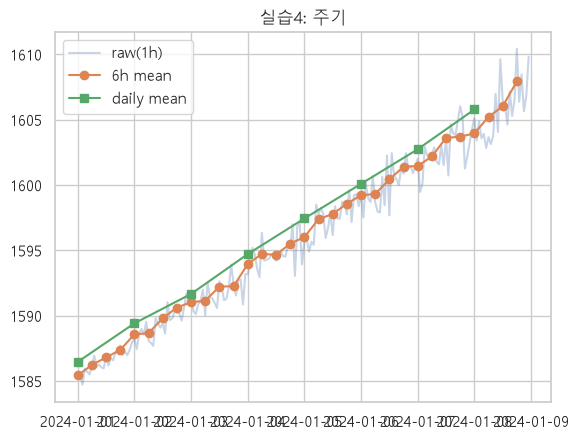

하루 평균 개수: 8


In [4]:
# [다운샘플링 주기에 따른 시계열의 주기적(Periodicity) 변동 관찰]
# 1. resample('6h').mean(): 6시간 단위로 축약하여 교대 근무 단위의 변동 패턴을 요약합니다.
# 2. resample('D').mean(): 하루('D', Day) 단위의 데이터를 요약하여 일별 등락만을 강조합니다.
# * 1시간 단위 신호에서 주기적으로 반복되는 일일 부하 변동(예: 낮에 운전이 많고 밤에 적어 온도가 오르내림)을
#   6시간 및 하루 평균선으로 축약하여 노이즈를 필터링하고 장기 운전 주기를 검증합니다.
# * `marker='o'`, `marker='s'` 등 마커 속성을 부여해 선 위에 샘플링 시점(점, 사각형)을 명시적으로 찍으면,
#   데이터 해상도가 얼만큼 거칠어졌는지 시각적으로 쉽게 비교할 수 있습니다.
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')


h6 = df['s_3'].resample('6h').mean()
day = df['s_3'].resample('D').mean()

plt.plot(df.index, df['s_3'], alpha=0.3, label='raw(1h)')
plt.plot(h6.index, h6, marker='o', label='6h mean')
plt.plot(day.index, day, marker='s', label='daily mean')
plt.legend()
plt.title('실습4: 주기')
plt.show()

print('하루 평균 개수:', len(day)) # 하루 평균 개수: 8